#### Experiment 2a
- 1D
- 5 electrodes - centre midline
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-10Hz
- Average by linear PSD, log PSD and SpecMod.

In [1]:
# Imports for functionality 
from dissertation_simulations.eeg_data import avg_psd_distribution_2D_eeg
from dissertation_simulations.eeg_data import avg_specmod_distribution_2D_eeg
from dissertation_simulations.eeg_data import sweep_electrodes_psd_2D_eeg
from dissertation_simulations.eeg_data import sweep_electrodes_specmod_2D_eeg
from dissertation_simulations.plotting import plot_summary_boxplots

import numpy as np
import json

from scipy.stats import ttest_rel

{'psd_average_space': 'linear', 'fit_freq_range': [2, 10]}
{'psd_average_space': 'log', 'fit_freq_range': [2, 10]}


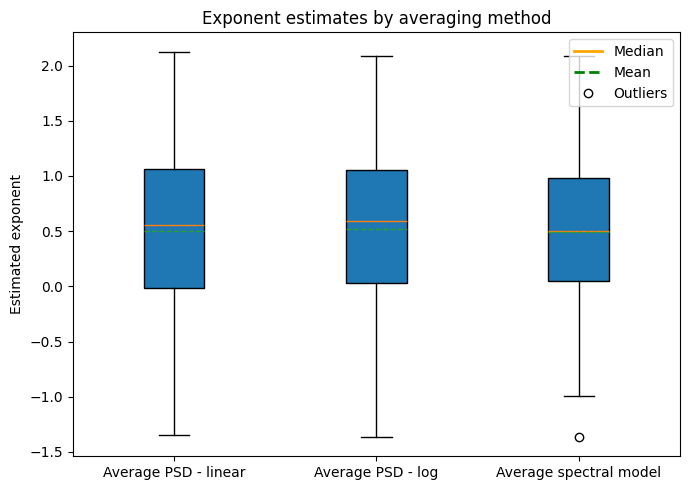

In [2]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E11", "E6", "Cz", "E62", "E75"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", fit_freq_range=[2, 10], plot=False, return_full=True
)

exp2a_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults1_eeg_psd_linear_5elec_midline.json", "w") as f:
    json.dump(exp2a_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", fit_freq_range=[2, 10], plot=False, return_full=True
)

exp2a_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults2_eeg_psd_log_5elec_midline.json", "w") as f:
    json.dump(exp2a_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", fit_freq_range=[2, 10], plot=False, return_full=True
)

exp2a_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults3_eeg_specmod_5elec_midline.json", "w") as f:
    json.dump(exp2a_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults1_eeg_psd_linear_5elec_midline.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults2_eeg_psd_log_5elec_midline.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults3_eeg_specmod_5elec_midline.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp2a_combined_plot_eeg_5elec_midline.png", dpi=300, bbox_inches="tight")

In [3]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults1_eeg_psd_linear_5elec_midline.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults2_eeg_psd_log_5elec_midline.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2aresults3_eeg_specmod_5elec_midline.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -1.457, p = 0.14799
PSD - linear averaging vs Spectral model: t = 0.546, p = 0.58613
PSD - log averaging vs Spectral model: t = 1.723, p = 0.08776


#### Experiment 2b
- 1D
- 5 electrodes - centre midline
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-20Hz
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear', 'fit_freq_range': [2, 20]}
{'psd_average_space': 'log', 'fit_freq_range': [2, 20]}


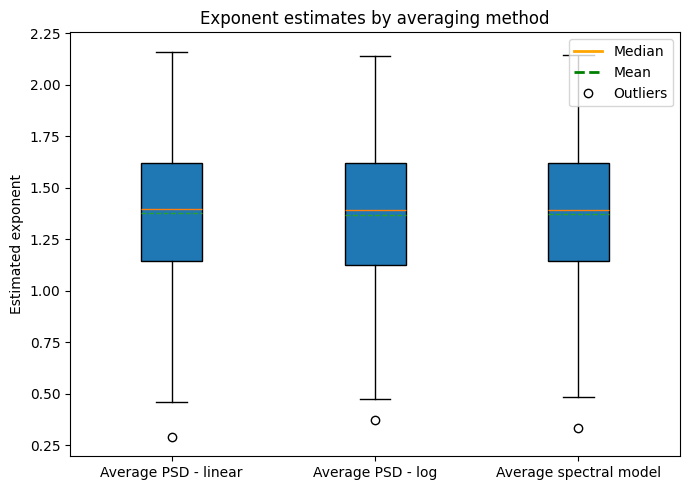

In [4]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E11", "E6", "Cz", "E62", "E75"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", fit_freq_range=[2, 20], plot=False, return_full=True
)

exp2b_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults1_eeg_psd_linear_5elec_midline.json", "w") as f:
    json.dump(exp2b_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", fit_freq_range=[2, 20], plot=False, return_full=True
)

exp2b_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults2_eeg_psd_log_5elec_midline.json", "w") as f:
    json.dump(exp2b_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", fit_freq_range=[2, 20], plot=False, return_full=True
)

exp2b_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults3_eeg_specmod_5elec_midline.json", "w") as f:
    json.dump(exp2b_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults1_eeg_psd_linear_5elec_midline.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults2_eeg_psd_log_5elec_midline.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults3_eeg_specmod_5elec_midline.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp2b_combined_plot_eeg_5elec_midline.png", dpi=300, bbox_inches="tight")

In [5]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults1_eeg_psd_linear_5elec_midline.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults2_eeg_psd_log_5elec_midline.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2bresults3_eeg_specmod_5elec_midline.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = 1.321, p = 0.18922
PSD - linear averaging vs Spectral model: t = 0.419, p = 0.67607
PSD - log averaging vs Spectral model: t = -1.366, p = 0.17470


#### Experiment 2c
- 1D
- 5 electrodes - centre midline
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-40Hz
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear', 'fit_freq_range': [2, 40]}
{'psd_average_space': 'log', 'fit_freq_range': [2, 40]}


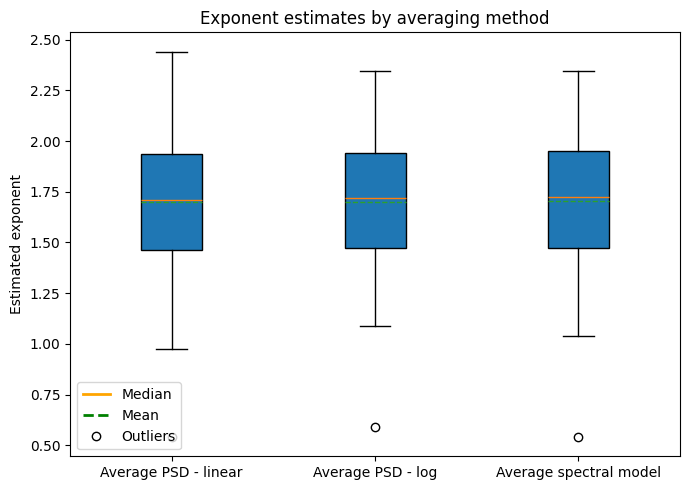

In [6]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E11", "E6", "Cz", "E62", "E75"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", fit_freq_range=[2, 40], plot=False, return_full=True
)

exp2c_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults1_eeg_psd_linear_5elec_midline.json", "w") as f:
    json.dump(exp2c_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", fit_freq_range=[2, 40], plot=False, return_full=True
)

exp2c_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults2_eeg_psd_log_5elec_midline.json", "w") as f:
    json.dump(exp2c_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", fit_freq_range=[2, 40], plot=False, return_full=True
)

exp2c_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults3_eeg_specmod_5elec_midline.json", "w") as f:
    json.dump(exp2c_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults1_eeg_psd_linear_5elec_midline.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults2_eeg_psd_log_5elec_midline.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults3_eeg_specmod_5elec_midline.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp2c_combined_plot_eeg_5elec_midline.png", dpi=300, bbox_inches="tight")

In [7]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults1_eeg_psd_linear_5elec_midline.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults2_eeg_psd_log_5elec_midline.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2cresults3_eeg_specmod_5elec_midline.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = 0.196, p = 0.84524
PSD - linear averaging vs Spectral model: t = -1.076, p = 0.28441
PSD - log averaging vs Spectral model: t = -2.064, p = 0.04134


#### Experiment 2d
- 1D
- 5 electrodes - centre midline
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-80Hz
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear', 'fit_freq_range': [2, 80]}
{'psd_average_space': 'log', 'fit_freq_range': [2, 80]}


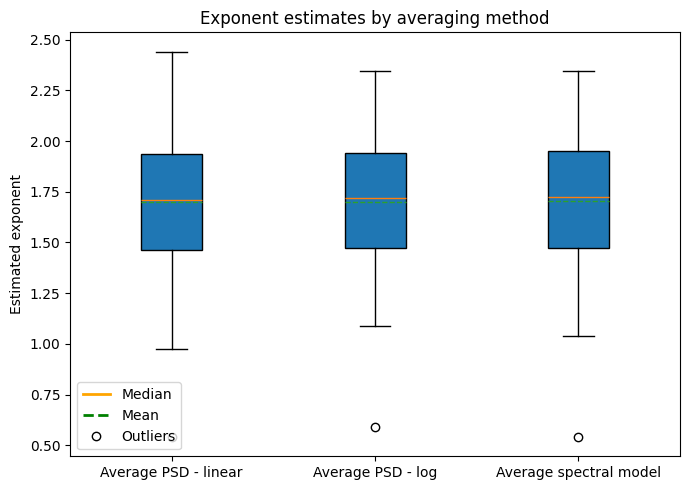

In [8]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E11", "E6", "Cz", "E62", "E75"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", fit_freq_range=[2, 80], plot=False, return_full=True
)

exp2d_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults1_eeg_psd_linear_5elec_midline.json", "w") as f:
    json.dump(exp2d_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", fit_freq_range=[2, 80], plot=False, return_full=True
)

exp2d_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults2_eeg_psd_log_5elec_midline.json", "w") as f:
    json.dump(exp2d_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", fit_freq_range=[2, 80], plot=False, return_full=True
)

exp2d_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults3_eeg_specmod_5elec_midline.json", "w") as f:
    json.dump(exp2d_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults1_eeg_psd_linear_5elec_midline.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults2_eeg_psd_log_5elec_midline.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults3_eeg_specmod_5elec_midline.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp2d_combined_plot_eeg_5elec_midline.png", dpi=300, bbox_inches="tight")

In [9]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults1_eeg_psd_linear_5elec_midline.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults2_eeg_psd_log_5elec_midline.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2dresults3_eeg_specmod_5elec_midline.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = 0.196, p = 0.84524
PSD - linear averaging vs Spectral model: t = -1.076, p = 0.28441
PSD - log averaging vs Spectral model: t = -2.064, p = 0.04134


#### Experiment 2e
- 1D
- 5 electrodes - centre midline
- Adjust the frequency range of the Spectral Model (default = 2-40Hz)
- Frequency range = 2-160Hz
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear', 'fit_freq_range': [2, 160]}
{'psd_average_space': 'log', 'fit_freq_range': [2, 160]}


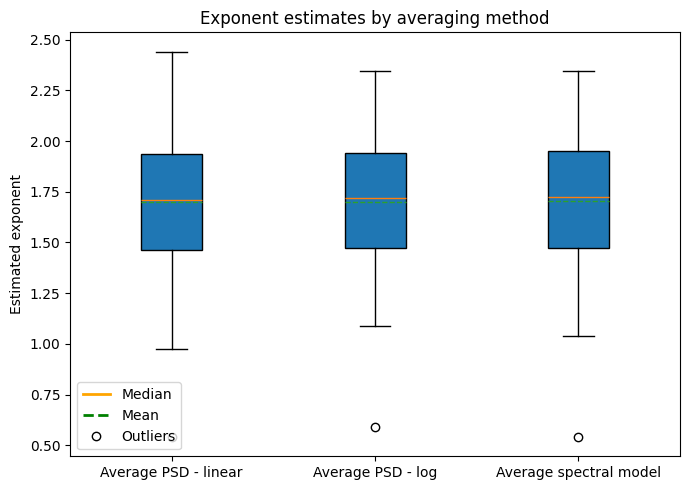

In [10]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E11", "E6", "Cz", "E62", "E75"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", fit_freq_range=[2, 160], plot=False, return_full=True
)

exp2e_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults1_eeg_psd_linear_5elec_midline.json", "w") as f:
    json.dump(exp2e_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", fit_freq_range=[2, 160], plot=False, return_full=True
)

exp2e_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults2_eeg_psd_log_5elec_midline.json", "w") as f:
    json.dump(exp2e_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", fit_freq_range=[2, 160], plot=False, return_full=True
)

exp2e_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults3_eeg_specmod_5elec_midline.json", "w") as f:
    json.dump(exp2e_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults1_eeg_psd_linear_5elec_midline.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults2_eeg_psd_log_5elec_midline.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults3_eeg_specmod_5elec_midline.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp2e_combined_plot_eeg_5elec_midline.png", dpi=300, bbox_inches="tight")

In [11]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults1_eeg_psd_linear_5elec_midline.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults2_eeg_psd_log_5elec_midline.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp2eresults3_eeg_specmod_5elec_midline.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = 0.196, p = 0.84524
PSD - linear averaging vs Spectral model: t = -1.076, p = 0.28441
PSD - log averaging vs Spectral model: t = -2.064, p = 0.04134
